In [2]:
# ============================================
# 1. EDA AND CORRELATION ANALYSIS
# ============================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Loading dataset
df=pd.read_csv(r'C:\Users\legen\Downloads\heart (1).csv')


Dataset shape: (918, 12)

Missing values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Target distribution:
HeartDisease
1    508
0    410
Name: count, dtype: int64
HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64

Descriptive Statistics:
              Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  918.000000  918.000000   918.000000  918.000000  918.000000   
mean    53.510893  132.396514   198.799564    0.233115  136.809368   
std      9.432617   18.514154   109.384145    0.423046   25.460334   
min     28.000000    0.000000     0.000000    0.000000   60.000000   
25%     47.000000  120.000000   173.250000    0.000000  120.000000   
50%     54.000000  130.000000   223.000000    0.000000  138.000000   
75%     60.000000  140.000000   267

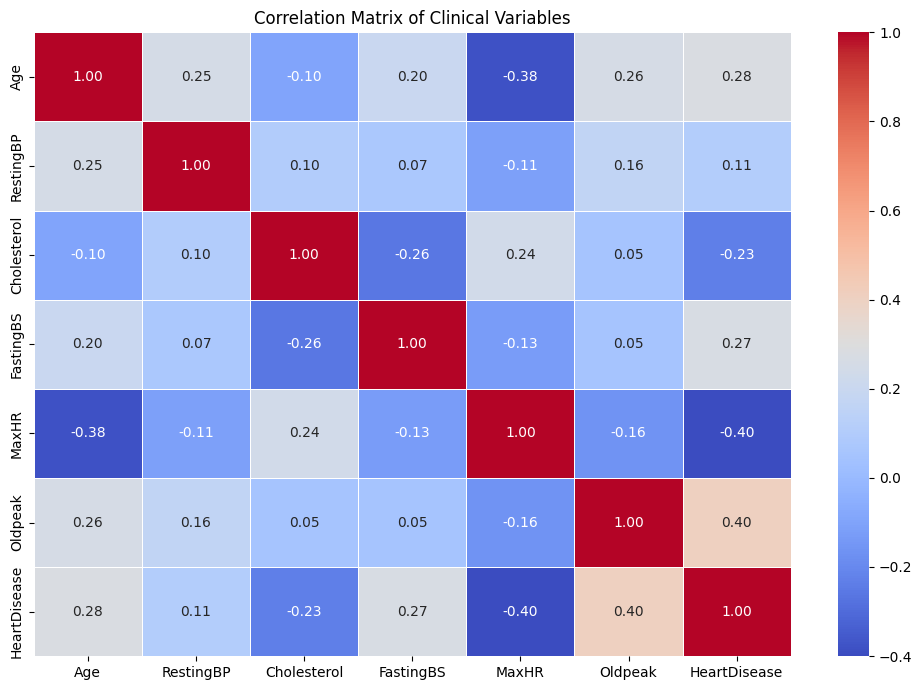

In [3]:
# Basic dataset information
print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["HeartDisease"].value_counts())
print(df["HeartDisease"].value_counts(normalize=True) * 100)

# Numerical variables
numeric_cols = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "FastingBS",
    "MaxHR",
    "Oldpeak",
    "HeartDisease"
]

# Descriptive statistics
print("\nDescriptive Statistics:")
print(df[numeric_cols].describe())

# Correlation matrix
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Clinical Variables")
plt.tight_layout()
plt.show()

In [4]:
# ============================================
# 2. RISK-FACTOR ANALYSIS
# ============================================

risk_factors = ["Age", "RestingBP", "Cholesterol"]

# Compare averages between patients with and without heart disease
risk_summary = df.groupby("HeartDisease")[risk_factors].agg(
    ["mean", "median", "std"]
)

print("Risk Factor Summary:")
print(risk_summary)

Risk Factor Summary:
                    Age                    RestingBP                    \
                   mean median       std        mean median        std   
HeartDisease                                                             
0             50.551220   51.0  9.444915  130.180488  130.0  16.499585   
1             55.899606   57.0  8.727056  134.185039  132.0  19.828685   

             Cholesterol                     
                    mean median         std  
HeartDisease                                 
0             227.121951  227.0   74.634659  
1             175.940945  217.0  126.391398  


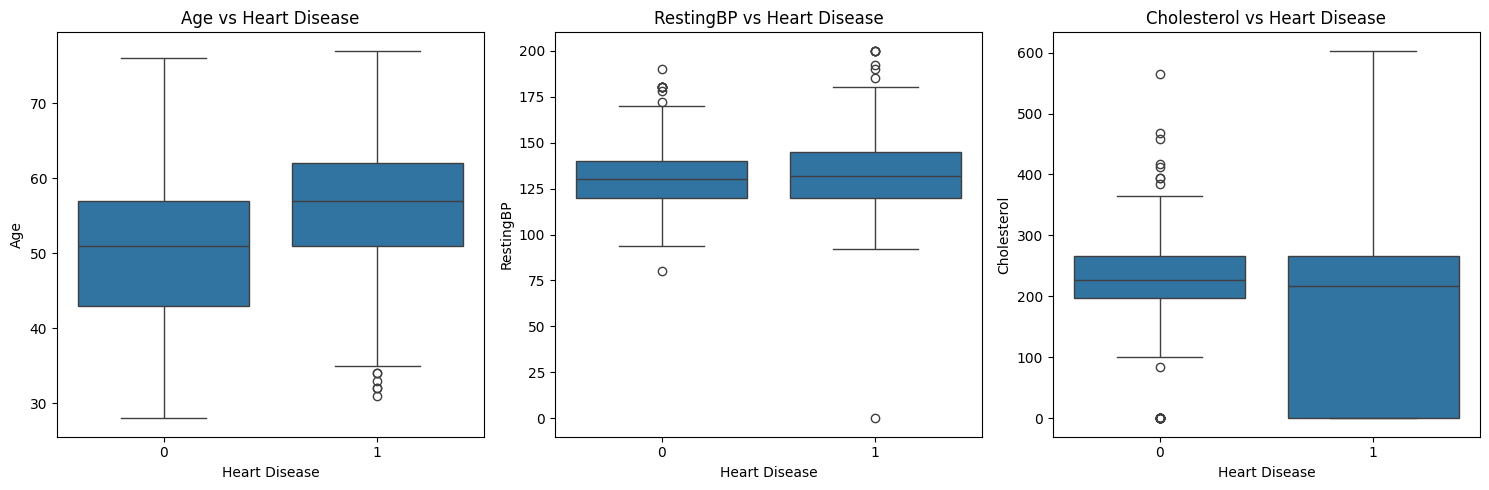

In [5]:
# Boxplots for major clinical variables
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, feature in zip(axes, risk_factors):
    sns.boxplot(
        data=df,
        x="HeartDisease",
        y=feature,
        ax=ax
    )

    ax.set_title(f"{feature} vs Heart Disease")
    ax.set_xlabel("Heart Disease")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

In [6]:
# ============================================
# 3. HYPOTHESIS TESTING
# ============================================

from scipy.stats import ttest_ind

results = []

for feature in risk_factors:

    group_0 = df[df["HeartDisease"] == 0][feature]
    group_1 = df[df["HeartDisease"] == 1][feature]

    # H0: Mean values are equal between the two groups
    # H1: Mean values are different

    statistic, p_value = ttest_ind(
        group_0,
        group_1,
        equal_var=False
    )

    results.append({
        "Variable": feature,
        "Mean_No_Disease": group_0.mean(),
        "Mean_Disease": group_1.mean(),
        "t_statistic": statistic,
        "p_value": p_value,
        "Significant": "Yes" if p_value < 0.05 else "No"
    })

hypothesis_results = pd.DataFrame(results)

print(hypothesis_results)

      Variable  Mean_No_Disease  Mean_Disease  t_statistic       p_value  \
0          Age        50.551220     55.899606    -8.822540  6.348337e-18   
1    RestingBP       130.180488    134.185039    -3.339492  8.732265e-04   
2  Cholesterol       227.121951    175.940945     7.626851  6.481236e-14   

  Significant  
0         Yes  
1         Yes  
2         Yes  


In [7]:
for _, row in hypothesis_results.iterrows():

    print(f"\nVariable: {row['Variable']}")
    print(f"Mean without heart disease: {row['Mean_No_Disease']:.2f}")
    print(f"Mean with heart disease: {row['Mean_Disease']:.2f}")
    print(f"t-statistic: {row['t_statistic']:.3f}")
    print(f"p-value: {row['p_value']:.5f}")

    if row["p_value"] < 0.05:
        print("Result: Statistically significant difference.")
    else:
        print("Result: No statistically significant difference.")


Variable: Age
Mean without heart disease: 50.55
Mean with heart disease: 55.90
t-statistic: -8.823
p-value: 0.00000
Result: Statistically significant difference.

Variable: RestingBP
Mean without heart disease: 130.18
Mean with heart disease: 134.19
t-statistic: -3.339
p-value: 0.00087
Result: Statistically significant difference.

Variable: Cholesterol
Mean without heart disease: 227.12
Mean with heart disease: 175.94
t-statistic: 7.627
p-value: 0.00000
Result: Statistically significant difference.


In [8]:
# ============================================
# 4. CLASSIFICATION MODEL EVALUATION
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

# Encode categorical variables
from sklearn.preprocessing import LabelEncoder, StandardScaler

cate_cols = X.select_dtypes(include=["object"]).columns.tolist()

for col in cate_cols:
    encoder = LabelEncoder()
    X[col] = encoder.fit_transform(X[col])

# Scale features
scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [9]:
# ============================================
# MODEL COMPARISON
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB()
}

results = []

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probability for ROC-AUC
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": auc
    })

results_df = pd.DataFrame(results)

print(results_df.round(4))

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression    0.8696     0.8482  0.9314    0.8879   0.8972
1                  KNN    0.8913     0.8942  0.9118    0.9029   0.9197
2                  SVM    0.8913     0.8661  0.9510    0.9065   0.9285
3        Decision Tree    0.7880     0.8119  0.8039    0.8079   0.7861
4          Naive Bayes    0.8913     0.8942  0.9118    0.9029   0.9280


In [10]:
# ============================================
# FINAL SVM EVALUATION
# ============================================

svm_model = SVC(
    probability=True,
    random_state=42
)

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)
y_prob = svm_model.predict_proba(X_test)[:, 1]

print("SVM Classification Report:")
print(classification_report(y_test, y_pred))

print("Accuracy:",
      round(accuracy_score(y_test, y_pred), 4))

print("Recall:",
      round(recall_score(y_test, y_pred), 4))

print("F1 Score:",
      round(f1_score(y_test, y_pred), 4))

print("ROC-AUC:",
      round(roc_auc_score(y_test, y_prob), 4))

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        82
           1       0.87      0.95      0.91       102

    accuracy                           0.89       184
   macro avg       0.90      0.88      0.89       184
weighted avg       0.89      0.89      0.89       184

Accuracy: 0.8913
Recall: 0.951
F1 Score: 0.9065
ROC-AUC: 0.9285


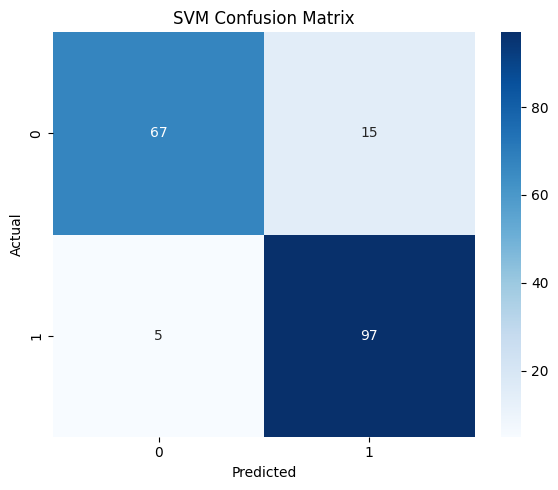

In [11]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [12]:
recall = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(
    f"SVM Recall: {recall * 100:.2f}%"
)

print(
    f"SVM ROC-AUC: {auc:.3f}"
)

SVM Recall: 95.10%
SVM ROC-AUC: 0.929
